### **Step-1 : Importing Dataset using Python Library**

In [2]:
import pandas as pd

# Load Dataset
file_path = "C:\\Users\\Admin\\Downloads\\PBL-2\\Review_db.csv"

df = pd.read_csv(file_path, encoding = "utf-8", low_memory = False)
df

,City,Place,Review,Rating,Name,Date,Raw_Review
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,5,Anonymous,NaN,Aamby valley is a beautiful place with its cle...
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4,Anonymous,NaN,Very well executed obt by Akshay.... Thanx as ...
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,5,Anonymous,NaN,Awesome experience at the ATV\nTracts and obst...
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,4,Anonymous,NaN,we visited the Aamby Valley yesterday for shor...
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,5,Anonymous,NaN,"Not far from Mumbai, this place is one of the ..."
...,...,...,...,...,...,...,...
1482461,Zuluk,Zuluk Wildlife Area,zuluk week march mst virgin unexplored region ...,3,Anonymous,NaN,We had been to zuluk in the last week of march...
1482462,Zuluk,Zuluk Wildlife Area,planned visit eastern sikkim time covered stat...,3,Anonymous,NaN,We planned to visit eastern part of Sikkim thi...
1482463,Zuluk,Zuluk Wildlife Area,excellent watched place east sikkim visited pl...,5,Anonymous,NaN,A excellent & must watched place for east sikk...
1482464,Zuluk,Zuluk Wildlife Area,beautiful areas sikkim falls eastern sikkim an...,4,Anonymous,NaN,One of the most beautiful areas in Sikkim... i...


### **Step-2 : Data Cleaning & Preprocessing (Stopwords, Lemmatization, TF-IDF)**

#### **# Check for missing values and return the sum for each column**

In [5]:
# Check for missing values

print("Missing Values :\n", df.isnull().sum())

Missing Values :
 City                0
Place               0
Review              0
Rating              0
Name                0
Date          1482466
Raw_Review          0
dtype: int64


#### **# Check for duplicate values and return the sum**

In [7]:
# Check for duplicates

print("\nDuplicate Rows :", df.duplicated().sum())


Duplicate Rows : 14220


#### **# Handle duplicates - remove duplicate rows and verify once again**

In [9]:
# Drop unnecessary columns

df.drop(columns = ["Name", "Date"], inplace = True)

#### **# Drop Unnecessary Columns from dataset**

In [11]:
# Remove duplicate rows

df = df.drop_duplicates()

# Verify

print("Duplicate Rows after removal :", df.duplicated().sum())

Duplicate Rows after removal : 0


#### **# Dataset after initial cleanup**

In [13]:
# Show dataset overview

print("\nDataset after initial cleanup :")
df.info()
df.head()


Dataset after initial cleanup :
<class 'pandas.core.frame.DataFrame'>
Index: 1468246 entries, 0 to 1482465
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   City        1468246 non-null  object
 1   Place       1468246 non-null  object
 2   Review      1468246 non-null  object
 3   Rating      1468246 non-null  int64 
 4   Raw_Review  1468246 non-null  object
dtypes: int64(1), object(4)
memory usage: 67.2+ MB


,City,Place,Review,Rating,Raw_Review
0,Aamby Valley City,19 Degree North,aamby valley beautiful place clear blue skies ...,5,Aamby valley is a beautiful place with its cle...
1,Aamby Valley City,19 Degree North,executed obt akshay thanx team thoroughly enjo...,4,Very well executed obt by Akshay.... Thanx as ...
2,Aamby Valley City,19 Degree North,awesome experience atv tracts obstacles mainta...,5,Awesome experience at the ATV\nTracts and obst...
3,Aamby Valley City,19 Degree North,visited aamby valley yesterday short excursion...,4,we visited the Aamby Valley yesterday for shor...
4,Aamby Valley City,19 Degree North,far mumbai place finest adventure places visit...,5,"Not far from Mumbai, this place is one of the ..."


#### **# Since we have two review columns (Review & Raw_Review), we need to check:**

#### 1. Are they similar? If so, we can keep only one.
#### 2. Which column contains better-quality text?

In [15]:
# Compare the first few entries of both columns

for i in range(5) :
    print(f"Review : {df['Review'].iloc[i]}")
    print(f"Raw Review : {df['Raw_Review'].iloc[i]}")
    print("-" * 50)

Review : aamby valley beautiful place clear blue skies fresh green grass family visited aamby valley celebrate mother birthday mom splendid time thanks pinky bharadwaj handling booking bombay
Raw Review : Aamby valley is a beautiful place with its clear blue skies and fresh green grass. My family and I visited aamby valley to celebrate my mother's birthday. My mom had the most splendid time. Thanks to Pinky Bharadwaj for handling our booking from Bombay. Together...
--------------------------------------------------
Review : executed obt akshay thanx team thoroughly enjoyed especially frame treasure hunt
Raw Review : Very well executed obt by Akshay.... Thanx as a team we thoroughly enjoyed especially A frame and treasure hunt
--------------------------------------------------
Review : awesome experience atv tracts obstacles maintained safe challenging blast good experience helpful instructors
Raw Review : Awesome experience at the ATV
Tracts and obstacles well maintained,
Very safe ye

#### **# Clean Text Data (Preprocessing)**

In [17]:
import re

# Function to clean text
def clean_text(text) :
    text = text.lower()       # Convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)       # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra spaces
    return text

# Apply Cleaning
df["Review"] = df["Review"].apply(clean_text)

# Check cleaned data
df["Review"].head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9004\1746549193.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Review"] = df["Review"].apply(clean_text)


0    aamby valley beautiful place clear blue skies ...
1    executed obt akshay thanx team thoroughly enjo...
2    awesome experience atv tracts obstacles mainta...
3    visited aamby valley yesterday short excursion...
4    far mumbai place finest adventure places visit...
Name: Review, dtype: object

### **# Final Cleanup (Drop Review)**

In [19]:
# Drop the 'Review' column since'Raw_Review' is better
df.drop(columns = ["Review"], inplace = True)

# Chech final columns
print("Final Columns in dataset :")
df.columns

Final Columns in dataset :


C:\Users\Admin\AppData\Local\Temp\ipykernel_9004\3381744228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns = ["Review"], inplace = True)


Index(['City', 'Place', 'Rating', 'Raw_Review'], dtype='object')

### **Step-2 : Sentiment Labeling (Based on Ratings)**
### **We'll now convert ratings into sentiment categories:**
##### 1. (1 to 2) : Negative
##### 2. ( 3 ): Neutral
##### 3. (4 - 5) : Positive

In [21]:
# Function to map ratings to sentiments
def label_sentiment(rating) :
    if rating <= 2 :
        return "Negative"
    elif rating  == 3 :
        return "Neutral"
    else :
        return "Positive"

# Apply function
df["Sentiment"] = df["Rating"].apply(label_sentiment)

# Show results
print(df[["Rating", "Sentiment"]].head(10))

   Rating Sentiment
0       5  Positive
1       4  Positive
2       5  Positive
3       4  Positive
4       5  Positive
5       5  Positive
6       5  Positive
7       4  Positive
8       3   Neutral
9       3   Neutral


C:\Users\Admin\AppData\Local\Temp\ipykernel_9004\3852047544.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sentiment"] = df["Rating"].apply(label_sentiment)


### **Step-3 : Text Preprocessing for NLP**
#### **- We will now prepare the Raw_Review column for machine learning**

#### **# Install NLP and Swifter Libraries**

#### **# Download Required NLTK Data**

In [25]:
import nltk

nltk.download('punkt')       # Tokenization (splitting sentences into words)
nltk.download('stopwords')   # Common words like "the", "is", "and"
nltk.download('wordnet')     # Lemmatization (converting "running" → "run")

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

#### **# Import Libraries**

In [27]:
import re
import swifter  # Import swifter for fast execution
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

#### **# Define Text Preprocessing Function**

In [29]:
# Initialize Lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to clean text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    
    words = word_tokenize(text)  # Tokenize text
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]  # Lemmatization & Stopword removal
    
    return " ".join(words)

#### **# Apply Preprocessing to a 30,000 Sample**

In [31]:
# Take a random sample of 30,000 reviews
df_sample = df.sample(30000, random_state = 42)

# Apply preprocessing using swifter(fastest method)
df_sample["Cleaned_Review"] = df_sample["Raw_Review"].swifter.apply(preprocess_text)

# Show cleaned text
print(df_sample[["Raw_Review", "Cleaned_Review"]].head(5))

Pandas Apply:   0%|          | 0/30000 [00:00<?, ?it/s]

                                                Raw_Review  \
657420   A must see if you are in kochi. Highly recomme...   
754123   A must visit when you are in Ladakh. The road ...   
1263959  Hanuman Vatika is a beautiful and Nice place t...   
412541   Excellent collection of extinct birds stuffed ...   
667786   This church is very big and very beautiful the...   

                                            Cleaned_Review  
657420   must see kochi highly recommended kathakali sh...  
754123   must visit ladakh road quite long rough part c...  
1263959  hanuman vatika beautiful nice place hangout sp...  
412541   excellent collection extinct bird stuffed well...  
667786   church big beautiful design church also attrac...  


### **Step-4 : Sentiment Analysis Model Training**

#### **Convert Text to Numerical Features**
##### **- We will use TF-IDF (Term Frequency-Inverse Document Frequency) to convert text into numbers.**

In [34]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


#### **# Apply TF-IDF Vectorization**

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features = 5000)       # Convert top 5000 words into numerical form

# Fit and transform text data 
X = tfidf.fit_transform(df_sample["Cleaned_Review"])     # Features(numerical form of text)
y = df_sample["Sentiment"]     # Labels(Positive, Neutral, Negative)

print("Shape of feature matrix :", X.shape)

Shape of feature matrix : (30000, 5000)


#### **# Handling Class Imbalance with SMOTE**

In [38]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split

# Step 1 : Split the dataset into Train & Test sets before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Step 2 : Check class distribution before resampling
print("Before resampling : ", Counter(y_train))

# Step 3 : Apply SMOTE only on training data
smote = SMOTE(sampling_strategy = 'auto', random_state = 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 4 : Check new class distribution 
print("After resampling : ", Counter(y_train_resampled))

Before resampling :  Counter({'Positive': 19527, 'Neutral': 3379, 'Negative': 1094})
After resampling :  Counter({'Neutral': 19527, 'Positive': 19527, 'Negative': 19527})


#### **# Train a Sentiment Analysis Model**
#### - We will use Logistic Regression (a simple and effective ML model).

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Split data into training (80%) and tsting (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Model Evaluation
print("Accuracy Score :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))

Accuracy Score : 0.8585

Classification Report :
               precision    recall  f1-score   support

    Negative       0.74      0.14      0.24       269
     Neutral       0.58      0.31      0.40       825
    Positive       0.88      0.99      0.93      4906

    accuracy                           0.86      6000
   macro avg       0.73      0.48      0.53      6000
weighted avg       0.83      0.86      0.83      6000



#### **- Why is Negative Sentiment Accuracy Low?**
##### **1. Imbalanced Data :** This dataset likely has way more positive reviews than negative ones.This causes the model to be biased toward predicting positive.
##### **2. TF-IDF Limitation :** Word meaning & order are ignored (e.g., "not good" and "good" have similar weights).

### **# Results Analysis:**
##### Our Logistic Regression model achieved 85.85% accuracy!

#### **However, there are some key observations:**
##### - Positive reviews are well-classified (F1-score: 0.93)
##### - Negative & Neutral reviews have lower recall (they are often misclassified as Positive)

### **Step-5 : Comparing performance of Logistic Regression Accuracy & SVM Accuracy to improve Model Performance**

#### **# 1 : Train an SVM Model**

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM Model
svm_model = SVC(kernel="linear")  # Linear kernel for text data
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test)

# Model Evaluation
print("SVM Accuracy Score:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy Score: 0.8653333333333333

Classification Report:
               precision    recall  f1-score   support

    Negative       0.67      0.23      0.35       269
     Neutral       0.58      0.42      0.49       825
    Positive       0.90      0.97      0.94      4906

    accuracy                           0.87      6000
   macro avg       0.72      0.54      0.59      6000
weighted avg       0.85      0.87      0.85      6000



#### **# 2 : Compare Models**
##### **- By comparing Logistic Regression Accuracy & SVM Accuracy we conclude that SVM performs significantly better.**
##### **- We can use BERT for higher accuracy & better text understanding but we are sticking with SVM.**

#### **# 3 : Fine-Tune SVM for Higher Accuracy, to improve SVM, we can tune hyperparameters**

In [48]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid = {
    "C": [0.1, 1],  # Regularization strength  # Fewer C values
    "kernel": ["linear", "rbf"],  # Type of SVM kernel
}

# Perform Grid search with 3-fold CV(Faster than 5-fold)
svm_tuned = GridSearchCV(SVC(), param_grid, cv = 3, verbose = 1, n_jobs = -1)
svm_tuned.fit(X_train, y_train)

# Predict on test data
y_pred_svm_tuned = svm_tuned.best_estimator_.predict(X_test)

# Model Evaluation
print("Best SVM Parameters : ", svm_tuned.best_params_)
print("Tuned SVM Accuracy :", accuracy_score(y_test, y_pred_svm_tuned))
print("\nClassification Report :\n", classification_report(y_test, y_pred_svm_tuned))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best SVM Parameters :  {'C': 1, 'kernel': 'linear'}
Tuned SVM Accuracy : 0.8653333333333333

Classification Report :
               precision    recall  f1-score   support

    Negative       0.67      0.23      0.35       269
     Neutral       0.58      0.42      0.49       825
    Positive       0.90      0.97      0.94      4906

    accuracy                           0.87      6000
   macro avg       0.72      0.54      0.59      6000
weighted avg       0.85      0.87      0.85      6000



##### **- Best SVM parameters: 'C': 1, 'kernel': 'linear', achieving 86.5% accuracy.**
##### **- Positive sentiment detection is highly accurate with a 0.94 F1-score.**
##### **- Negative and neutral sentiments have lower recall, indicating some difficulty in correctly identifying these classes.**

### **Step-6 : Proceed with Model Evaluation & Recommendation System.**

In [51]:
def recommend_places(df, place_name) :
    place_name = place_name.lower()
    sentiment_counts = df[df["Place"].str.lower() == place_name] ["Sentiment"].value_counts()

    if sentiment_counts.empty :
        return f"No reviews found for '{place_name}'. Try another place."

    # Get sentiment breakdown
    total_reviews = sentiment_counts.sum()
    pos_count = sentiment_counts.get("Positive", 0)
    neu_count = sentiment_counts.get("Neutral", 0)
    neg_count = sentiment_counts.get("Negative", 0)
    
    # Calculate percentages
    pos_percent = (pos_count / total_reviews) * 100
    neu_percent = (neu_count / total_reviews) * 100
    neg_percent = (neg_count / total_reviews) * 100

    # Recommendation logic
    if pos_count > neg_count :
        recommendation = f"\033[1mRecommended\033[0m : {place_name.capitalize()}"
    else :
        recommendation = f"\033[1mNot Recommended\033[0m : {place_name.capitalize()}"

    # Display sentiment analysis recommendation
    result = f"""
    \033[1mPlace\033[0m : {place_name.capitalize()}
    \033[1mTotal Reviews\033[0m : {total_reviews}

    \033[1mPositive\033[0m : {pos_count} ({pos_percent : .2f}%)
    \033[1mNeutral\033[0m : {neu_count} ({neu_percent : .2f}%)
    \033[1mNegative\033[0m : {neg_count} ({neg_percent : .2f}%)

    {recommendation}
    """
    return result

# Show available places
print("Available places :", list(df_sample["Place"].unique()))       # Show first 50 places

# Take user input
user_input = input("\nEnter a place name from the list : ")
print(recommend_places(df_sample, user_input))

Available places : ['Kerala Kathakali Centre', 'Pangong Tso', 'Hanuman Vatika', 'Gujari Mahal Archaeological Museum', 'St Judes Church', 'Albert Hall Museum', 'Sayaji Baug', 'Agra Fort', 'Randha Falls', 'Mount Harriet National Park', 'City Palace of Udaipur', 'ISKCON Baroda, Sri Sri Radha Shyamasundar Mandir Temple', 'Ranakpur Jain Temple', 'Happy Valley Tea Estate', 'Mattancherry Palace', 'Salim Singh-ki Haveli', "Maharaja's Palace", 'Global Vipassana Pagoda', 'Wonderla Amusement Park', 'Jagdish Temple', 'Auto World Vintage Car Museum', 'Shivasamudram Falls', 'VGP Snow Kingdom', 'Chinese Fishing Nets', 'Borra Caves', 'Buddha Smriti Park', 'Funcity', 'Company Garden', 'Arulmigu Swaminatha Swami Temple, Swamimalai', 'Gateway of India', 'Dargah Shariff', "Rita's Gourmet Goa", 'Mahakali Temple', 'Mountain Top Camping', 'Sarnath', 'Visvesvaraya Industrial and Technological Museum', 'Khanderao Market', 'Snow View Point', 'Swaminarayan Akshardham', 'Narayani Dham Temple', 'Kausani Tea Estate


Enter a place name from the list :  Mallalli Falls



    Place : Mallalli falls
    Total Reviews : 1

    Positive : 1 ( 100.00%)
    Neutral : 0 ( 0.00%)
    Negative : 0 ( 0.00%)

    Recommended : Mallalli falls
    


### **Step-7 : How to Visually Represent Sentiment Analysis Project?**

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

#### **1. Sentiment Distribution (Bar Chart)**

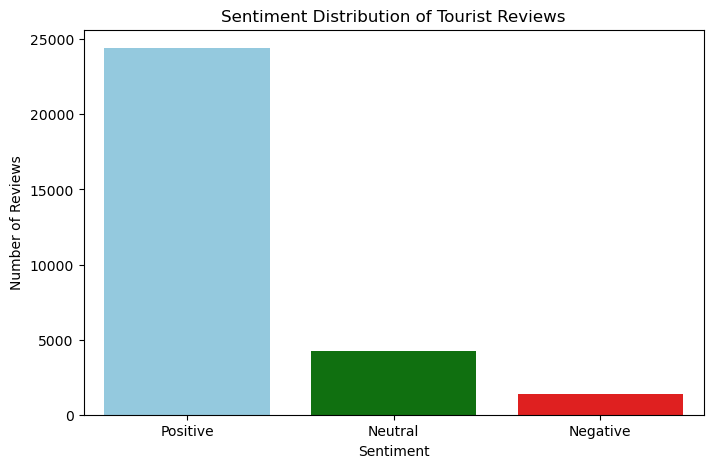

In [55]:
# Count the number of reviews per sentiment
sentiment_counts = df_sample["Sentiment"].value_counts()

# Plot bar chart
plt.figure(figsize = (8, 5))
sns.barplot(x = sentiment_counts.index, y = sentiment_counts.values, palette = ["skyblue", "green", "red"])
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution of Tourist Reviews")
plt.show()

##### **- Shows the proportion of Positive(sky-blue), Neutral(green), and Negative(red) reviews.**
##### **- Majority of reviews are positive, indicating overall tourist satisfaction.**
##### **- Neutral reviews are significantly lower, suggesting mixed experiences for some visitors.**
##### **- Negative reviews are minimal, implying that most tourists had a good experience.**

#### **2. Top 10 Most Reviewed Places (Bar Chart)**

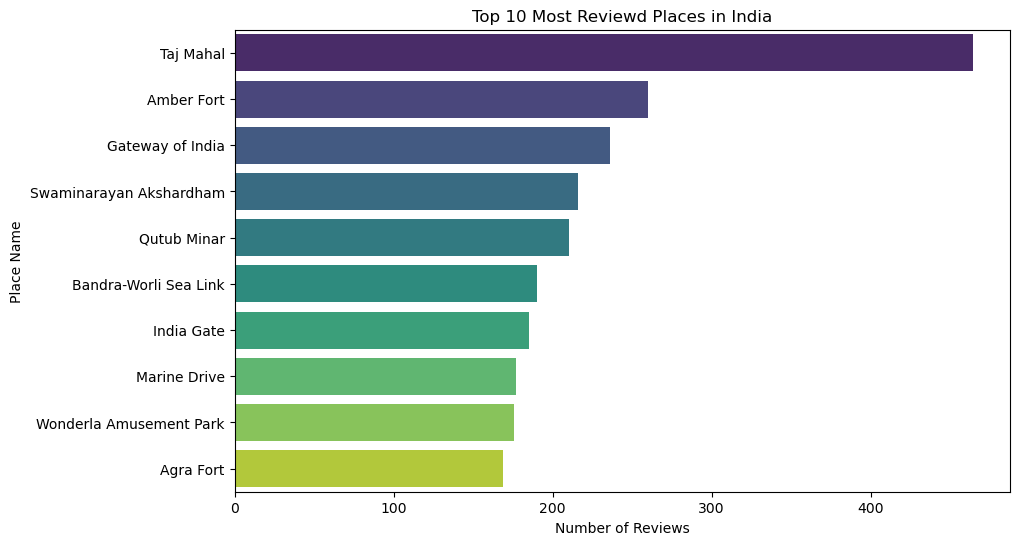

In [58]:
# Count the number of reviews per sentiment
top_places = df_sample["Place"].value_counts().head(10)

# Plot bar chart 
plt.figure(figsize = (10, 6))
sns.barplot(y = top_places.index, x = top_places.values, palette = "viridis")
plt.xlabel("Number of Reviews")
plt.ylabel("Place Name")
plt.title("Top 10 Most Reviewd Places in India")
plt.show()

##### **- Displays which places have the highest number of reviews.**
##### **- Taj Mahal has the highest number of reviews, indicating its strong popularity among tourists.**
##### **- Historical landmarks dominate the list, showing high tourist interest in cultural and heritage sites.**
##### **- Amusement parks and modern attractions have fewer reviews, suggesting they are less frequently visited compared to historical sites.**

#### **3. Sentiment Distribution for Specific Places (Stacked Bar Chart)**

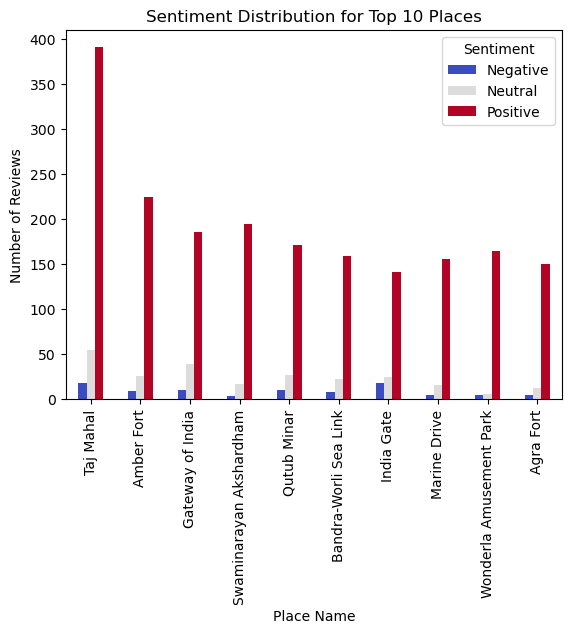

In [61]:
# Pivot table for sentiment per place
sentiment_per_place = df_sample.groupby(["Place", "Sentiment"]).size().unstack()

# Select top 10 reviewed places
top_places = df_sample["Place"].value_counts().head(10).index
sentiment_per_place = sentiment_per_place.loc[top_places]

# Plot stacked bar chart
sentiment_per_place.plot(kind = "bar", colormap = "coolwarm")
plt.xlabel("Place Name")
plt.ylabel("Number of Reviews")
plt.title("Sentiment Distribution for Top 10 Places")
plt.xticks(rotation = 90)
plt.legend(title = "Sentiment")
plt.show()

##### **- Shows how each place is rated (Positive, Neutral, Negative).**
##### **- All top 10 places have a high number of positive reviews, indicating strong visitor satisfaction.**
##### **- Negative and neutral reviews are significantly lower, suggesting that most tourists have a good experience.**
##### **- Taj Mahal leads in total reviews and positive sentiment, reinforcing its status as the most favored tourist destination.**

#### **4. Word Cloud of Most Common Words in Reviews**

In [64]:
!pip install wordcloud

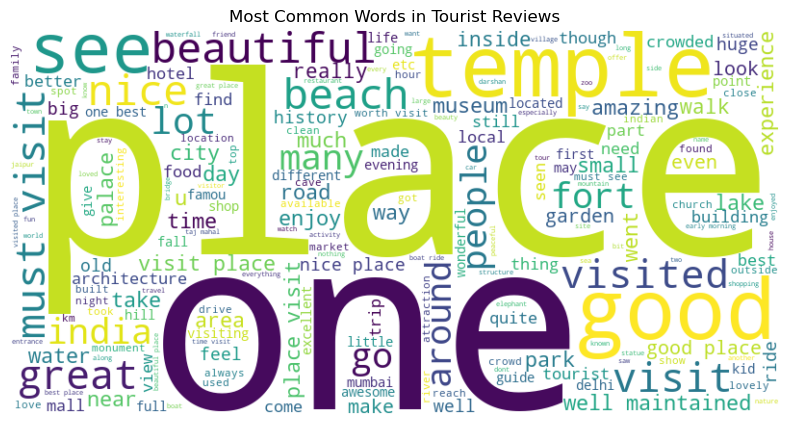

In [65]:

from wordcloud import WordCloud

# Combine all reviews into one text
all_reviews = " ".join(df_sample["Cleaned_Review"])

# Generate WordCloud
wordcloud = WordCloud(width = 800, height = 400, background_color = "white").generate(all_reviews)

# Display WordCloud
plt.figure(figsize = (10, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Most Common Words in Tourist Reviews")
plt.show()

##### **- Highlights the most frequently used words in tourist reviews.**
##### **- Words like "place," "one," "temple," and "beach" appear frequently, indicating common themes in tourist reviews.**
##### **- Positive words such as "good," "beautiful," "amazing," and "nice" dominate, suggesting a generally favorable sentiment.**
##### **- Mentions of specific locations like "lake," "road," and "palace" highlight key attractions tourists often discuss.**

#### **5. Sentiment Pie Chart**

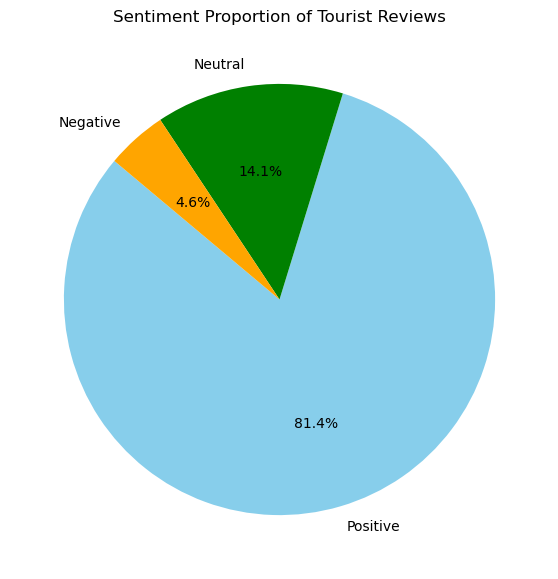

In [68]:
# Count sentiment categories
sentiment_counts = df_sample["Sentiment"].value_counts()

# Plot pie chart
plt.figure(figsize = (7, 7))
plt.pie(sentiment_counts, labels = sentiment_counts.index, autopct = "%1.1f%%", colors = ["skyblue", "green", "orange"], startangle = 140)
plt.title("Sentiment Proportion of Tourist Reviews")
plt.show()

##### **- Gives a quick overview of sentiment proportions.**
##### **- The majority of tourist reviews (81.4%) are positive, indicating a highly favorable visitor experience.**
##### **- Neutral reviews (14.1%) suggest that some tourists had an average or mixed experience.**
##### **- Negative reviews (4.6%) are minimal, showing that only a small fraction of visitors had a poor experience.**